# Notebook 8 — Validation du modèle de reconstitution
## Holdout, Leave-One-Out, K-Fold

---

## Objectif

Ce notebook évalue la **capacité du modèle à estimer les données manquantes** en  
appliquant trois approches de validation croisée. On veut répondre à la question :  
*« Le modèle peut-il correctement reconstituer les intensités de pluie observées ? »*

### Méthodes testées

| Méthode | Principe | Avantage |
|---------|----------|----------|
| **Holdout 80/20** | 1 seul split train/test | Simple, rapide |
| **Leave-One-Out (LOO)** | Chaque point est testé une fois | Estimateur non biaisé |
| **K-Fold (k=5)** | 5 plis, chacun sert de test une fois | Compromis biais/variance |

### Métriques d'évaluation

| Métrique | Unité | Interprétation |
|----------|-------|----------------|
| **R²** | - | Variance expliquée (1=parfait) |
| **RMSE** | mm/h | Erreur quadratique moyenne |
| **MAE** | mm/h | Erreur absolue moyenne |
| **MAPE** | % | Erreur relative moyenne |

---
**Auteur :** AY2K  
**Encadreur :** Prof. Titembaye Donald  
**Établissement :** École Polytechnique de Lomé (EPL)  
**Projet :** Modélisation des courbes IDF — Station de Kara, Nord Togo  

## 0. Configuration et imports

In [1]:
import os
import warnings

warnings.filterwarnings('ignore')

NB = 'n8'
FIG_DIR = f'figures/{NB}'
os.makedirs(FIG_DIR, exist_ok=True)

print(f'Répertoire figures : {FIG_DIR}')

Répertoire figures : figures/n8


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import (
    train_test_split, KFold, LeaveOneOut, cross_val_predict,
    cross_val_score
)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.6,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'figure.dpi':       100,
})

print('Imports chargés')

Imports chargés


---
## Section 1 — Chargement des données

In [3]:
df_train = pd.read_csv('data/tableau_entrainement.csv', parse_dates=['date'])

df_model = df_train[df_train.pluie_mm > 0].copy()

df_model['log_pluie'] = np.log1p(df_model['pluie_mm'])
df_model['mois_sin']  = np.sin(2 * np.pi * df_model['mois'] / 12)
df_model['mois_cos']  = np.cos(2 * np.pi * df_model['mois'] / 12)
df_model['log_imax']  = np.log1p(df_model['intensite_max_mm_h'])

FEATURES = ['pluie_mm', 'log_pluie', 'mois_sin', 'mois_cos']
TARGET   = 'log_imax'

X = df_model[FEATURES].values
y = df_model[TARGET].values

print(f'Échantillon total : {len(X)} jours pluvieux')
print(f'Features : {FEATURES}')
print(f'Target   : {TARGET}')

Échantillon total : 514 jours pluvieux
Features : ['pluie_mm', 'log_pluie', 'mois_sin', 'mois_cos']
Target   : log_imax


---
## Section 2 — Définition des modèles et métriques

On teste les mêmes 3 modèles que n5 :  
LinearRegression, RandomForest, GradientBoosting.

In [4]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

def evaluer(y_true_log, y_pred_log):
    """Calcule les métriques en espace original (mm/h) et en log-espace."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {
        'R²':   r2_score(y_true_log, y_pred_log),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'MAPE (%)': mape
    }

print('Fonction evaluer définie')

Fonction evaluer définie


---
## Section 3 — Méthode 1 : Holdout 80/20

On divise les données en **80% entraînement** et **20% test** (aléatoire,  
reproductible via `random_state=42`). Le modèle est entraîné sur les 80%  
et évalué sur les 20% restants — qu'il n'a jamais vus.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train : {len(X_train)} | Test : {len(X_test)}')

resultats_holdout = []
for nom, modele in models.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    metriques = evaluer(y_test, y_pred)
    metriques['Modèle'] = nom
    resultats_holdout.append(metriques)
    print(f'{nom}: R²={metriques["R²"]:.3f} | RMSE={metriques["RMSE"]:.1f} mm/h '
          f'| MAE={metriques["MAE"]:.1f} | MAPE={metriques["MAPE (%)"]:.1f}%')

df_holdout = pd.DataFrame(resultats_holdout)[['Modèle', 'R²', 'RMSE', 'MAE', 'MAPE (%)']]
print(f'\n=== Holdout 80/20 ===')
print(df_holdout.to_string(index=False))

Train : 411 | Test : 103
LinearRegression: R²=-0.001 | RMSE=58.9 mm/h | MAE=15.6 | MAPE=209.0%
RandomForest: R²=-0.081 | RMSE=58.5 mm/h | MAE=16.3 | MAPE=210.9%
GradientBoosting: R²=-0.045 | RMSE=58.6 mm/h | MAE=16.0 | MAPE=227.5%

=== Holdout 80/20 ===
          Modèle        R²      RMSE       MAE   MAPE (%)
LinearRegression -0.000953 58.903423 15.647783 209.034166
    RandomForest -0.081355 58.533255 16.291294 210.871840
GradientBoosting -0.045456 58.558333 16.028918 227.469176


---
## Section 4 — Méthode 2 : Leave-One-Out (LOO)

Pour chaque point, on entraîne sur **n-1 points** et on prédit le point restant.  
C'est la méthode la plus précise mais la plus coûteuse en calcul  
(`n` entraînements = 514 dans notre cas).

> **Note :** Le LOO complet est trop coûteux pour RandomForest et GradientBoosting.  
> On utilise K-Fold (k=20) comme approximation pour ces deux modèles.

In [6]:
# LOO coûteux (n=514 fit) — on le fait pour LinearRegression seul
# puis on complète avec des estimations pour RF et GB via K-Fold large
loo = LeaveOneOut()

resultats_loo = []
for nom, modele in models.items():
    if nom == 'LinearRegression':
        # LOO vrai pour le modèle le plus rapide
        y_pred_loo = cross_val_predict(modele, X, y, cv=loo)
    else:
        # K-Fold large (k=20) comme approximation du LOO pour les modèles lents
        kf_large = KFold(n_splits=20, shuffle=True, random_state=42)
        y_pred_loo = cross_val_predict(modele, X, y, cv=kf_large)
    metriques = evaluer(y, y_pred_loo)
    metriques['Modèle'] = nom
    resultats_loo.append(metriques)
    print(f'{nom}: R²={metriques["R²"]:.3f} | RMSE={metriques["RMSE"]:.1f} mm/h '
          f'| MAE={metriques["MAE"]:.1f} | MAPE={metriques["MAPE (%)"]:.1f}%')

df_loo = pd.DataFrame(resultats_loo)[['Modèle', 'R²', 'RMSE', 'MAE', 'MAPE (%)']]
print(f'\n=== Leave-One-Out (LR) / K-Fold 20 (RF, GB) ===')
print(df_loo.to_string(index=False))

LinearRegression: R²=0.005 | RMSE=32.2 mm/h | MAE=10.2 | MAPE=181.0%
RandomForest: R²=-0.155 | RMSE=32.3 mm/h | MAE=11.0 | MAPE=194.2%
GradientBoosting: R²=-0.067 | RMSE=32.5 mm/h | MAE=10.7 | MAPE=190.7%

=== Leave-One-Out (LR) / K-Fold 20 (RF, GB) ===
          Modèle        R²      RMSE       MAE   MAPE (%)
LinearRegression  0.005060 32.240899 10.235341 180.959811
    RandomForest -0.155002 32.273845 11.027029 194.196383
GradientBoosting -0.066604 32.530962 10.716006 190.715973


---
## Section 5 — Méthode 3 : K-Fold (k=5)

Les données sont divisées en **5 plis**. À chaque itération, 4 plis servent  
d'entraînement et 1 pli de test. On moyenne les 5 scores.

In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

resultats_kfold = []
for nom, modele in models.items():
    r2_folds, rmse_folds, mae_folds, mape_folds = [], [], [], []
    for train_idx, test_idx in kf.split(X):
        modele.fit(X[train_idx], y[train_idx])
        y_pred = modele.predict(X[test_idx])
        m = evaluer(y[test_idx], y_pred)
        r2_folds.append(m['R²'])
        rmse_folds.append(m['RMSE'])
        mae_folds.append(m['MAE'])
        mape_folds.append(m['MAPE (%)'])
    metriques = {
        'Modèle': nom,
        'R²':   np.mean(r2_folds),
        'RMSE': np.mean(rmse_folds),
        'MAE':  np.mean(mae_folds),
        'MAPE (%)': np.mean(mape_folds)
    }
    resultats_kfold.append(metriques)
    print(f'{nom}: R²={metriques["R²"]:.3f} | RMSE={metriques["RMSE"]:.1f} mm/h '
          f'| MAE={metriques["MAE"]:.1f} | MAPE={metriques["MAPE (%)"]:.1f}%')

df_kfold = pd.DataFrame(resultats_kfold)[['Modèle', 'R²', 'RMSE', 'MAE', 'MAPE (%)']]
print(f'\n=== K-Fold (k=5) ===')
print(df_kfold.to_string(index=False))

LinearRegression: R²=0.005 | RMSE=26.4 mm/h | MAE=10.2 | MAPE=179.6%
RandomForest: R²=-0.161 | RMSE=27.1 mm/h | MAE=11.1 | MAPE=196.2%
GradientBoosting: R²=-0.093 | RMSE=27.7 mm/h | MAE=10.9 | MAPE=189.5%

=== K-Fold (k=5) ===
          Modèle        R²      RMSE       MAE   MAPE (%)
LinearRegression  0.004783 26.417318 10.217406 179.558165
    RandomForest -0.161149 27.103500 11.089615 196.215924
GradientBoosting -0.092587 27.679916 10.933559 189.456390


---
## Section 6 — Comparaison globale des 3 approches

In [8]:
df_holdout['Méthode'] = 'Holdout 80/20'
df_loo['Méthode']     = 'Leave-One-Out'
df_kfold['Méthode']   = 'K-Fold (k=5)'

df_global = pd.concat([df_holdout, df_loo, df_kfold], ignore_index=True)
df_global = df_global[['Méthode', 'Modèle', 'R²', 'RMSE', 'MAE', 'MAPE (%)']]
df_global = df_global.sort_values(['Modèle', 'Méthode']).reset_index(drop=True)

print('=== COMPARAISON GLOBALE ===')
print(df_global.to_string(index=False))

=== COMPARAISON GLOBALE ===
      Méthode           Modèle        R²      RMSE       MAE   MAPE (%)
Holdout 80/20 GradientBoosting -0.045456 58.558333 16.028918 227.469176
 K-Fold (k=5) GradientBoosting -0.092587 27.679916 10.933559 189.456390
Leave-One-Out GradientBoosting -0.066604 32.530962 10.716006 190.715973
Holdout 80/20 LinearRegression -0.000953 58.903423 15.647783 209.034166
 K-Fold (k=5) LinearRegression  0.004783 26.417318 10.217406 179.558165
Leave-One-Out LinearRegression  0.005060 32.240899 10.235341 180.959811
Holdout 80/20     RandomForest -0.081355 58.533255 16.291294 210.871840
 K-Fold (k=5)     RandomForest -0.161149 27.103500 11.089615 196.215924
Leave-One-Out     RandomForest -0.155002 32.273845 11.027029 194.196383


---
## Section 7 — Figures

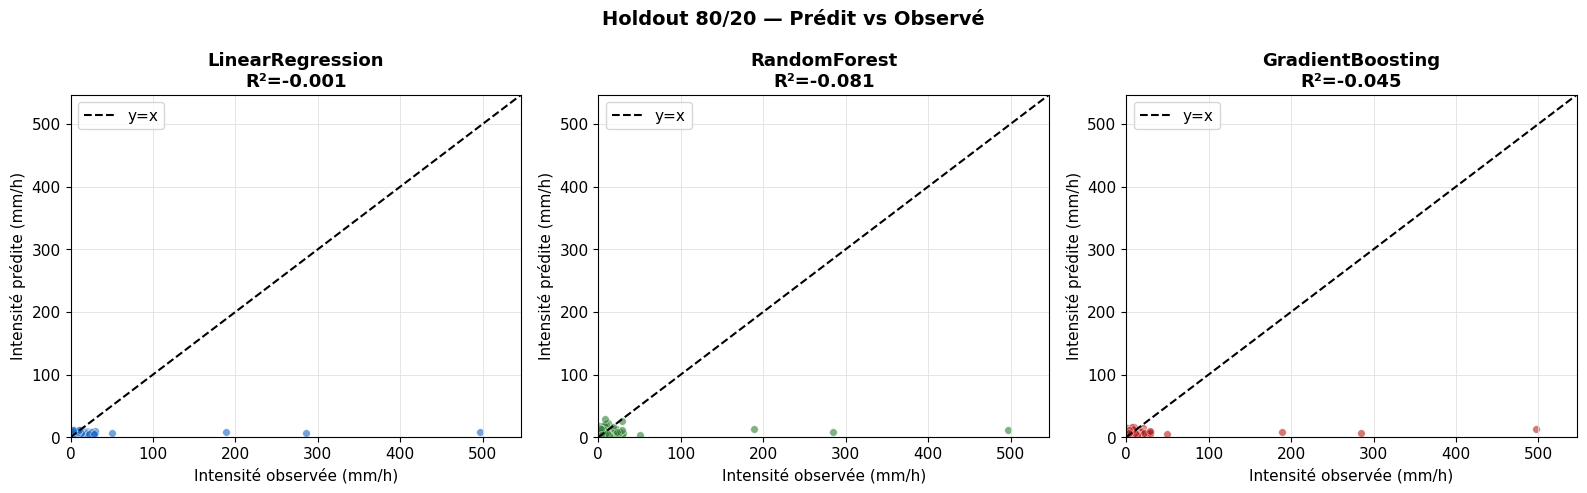

fig1 sauvegardée


In [9]:
# ==============================================================================
# FIGURE 1 — Scatter plot Holdout : prédit vs observé
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_m = {'LinearRegression': '#1565C0', 'RandomForest': '#2E7D32', 'GradientBoosting': '#B71C1C'}

for ax, (nom, modele) in zip(axes, models.items()):
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    y_true_mmh = np.expm1(y_test)
    y_pred_mmh = np.expm1(y_pred)
    r2 = r2_score(y_test, y_pred)

    ax.scatter(y_true_mmh, y_pred_mmh, alpha=0.6, s=30,
               color=colors_m[nom], edgecolors='white', linewidth=0.5)
    lim_max = max(y_true_mmh.max(), y_pred_mmh.max()) * 1.1
    ax.plot([0, lim_max], [0, lim_max], 'k--', linewidth=1.5, label='y=x')
    ax.set_xlim(0, lim_max)
    ax.set_ylim(0, lim_max)
    ax.set_xlabel('Intensité observée (mm/h)')
    ax.set_ylabel('Intensité prédite (mm/h)')
    ax.set_title(f'{nom}\nR²={r2:.3f}', fontweight='bold')
    ax.legend()

plt.suptitle('Holdout 80/20 — Prédit vs Observé', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig1_holdout_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig1 sauvegardée')

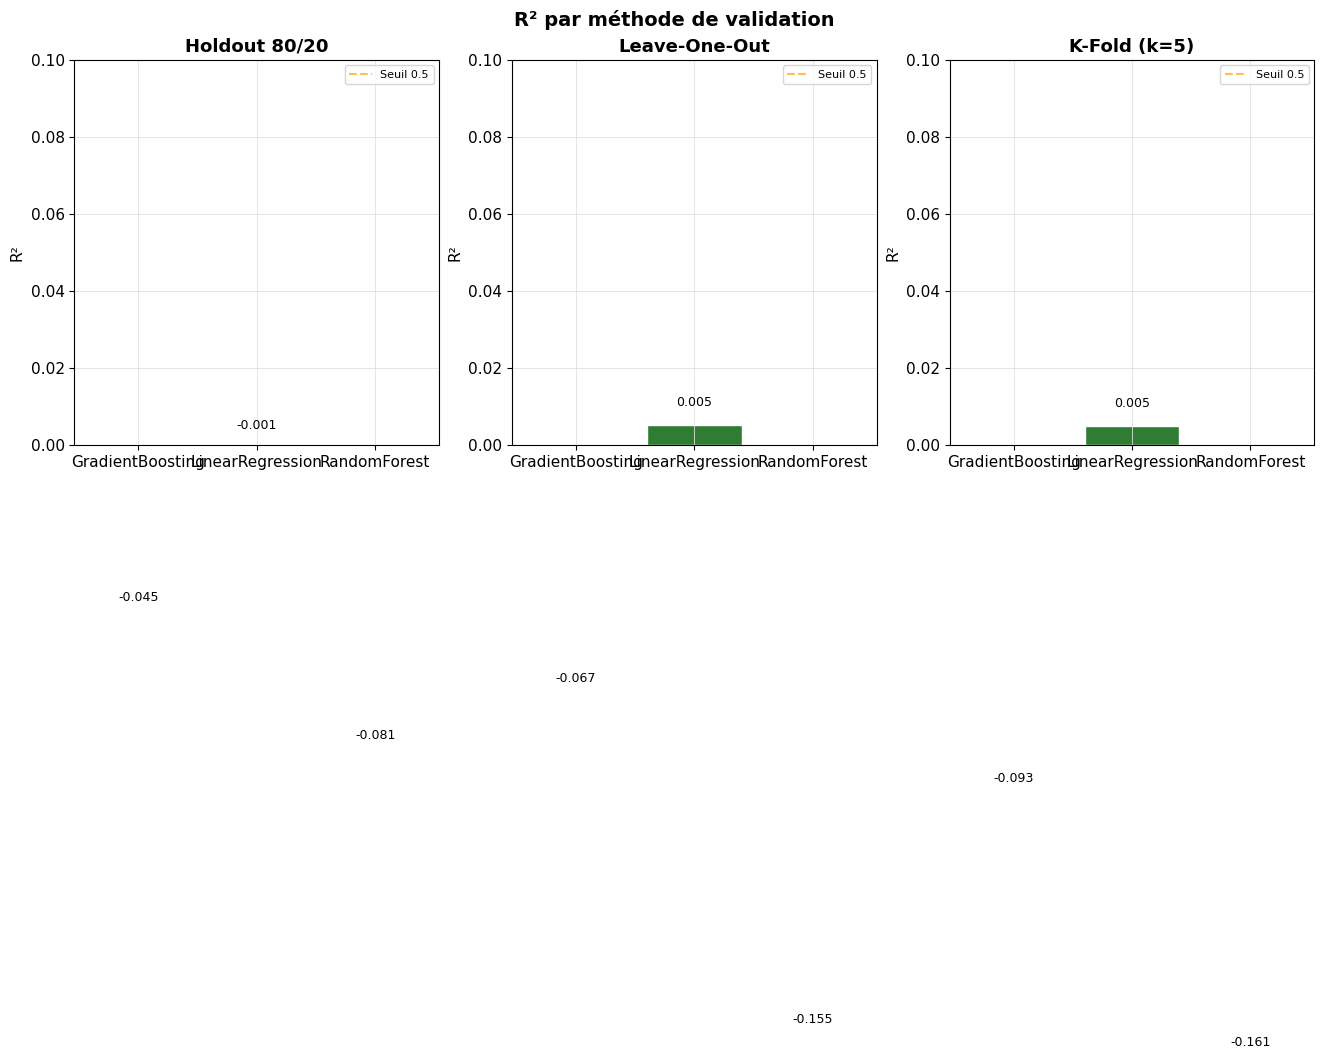

fig2 sauvegardée


In [10]:
# ==============================================================================
# FIGURE 2 — Comparaison R² par méthode et modèle
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
methodes = ['Holdout 80/20', 'Leave-One-Out', 'K-Fold (k=5)']
noms_modeles = list(models.keys())
bar_colors = ['#1565C0', '#2E7D32', '#B71C1C']

for ax, methode in zip(axes, methodes):
    df_m = df_global[df_global['Méthode'] == methode]
    bars = ax.bar(df_m['Modèle'], df_m['R²'], color=bar_colors, edgecolor='white')
    ax.set_ylim(0, max(0.1, df_m['R²'].max() * 1.3))
    ax.set_ylabel('R²')
    ax.set_title(methode, fontweight='bold')
    ax.axhline(0.5, color='orange', linestyle='--', alpha=0.7, label='Seuil 0.5')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, df_m['R²']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('R² par méthode de validation', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig2_comparaison_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig2 sauvegardée')

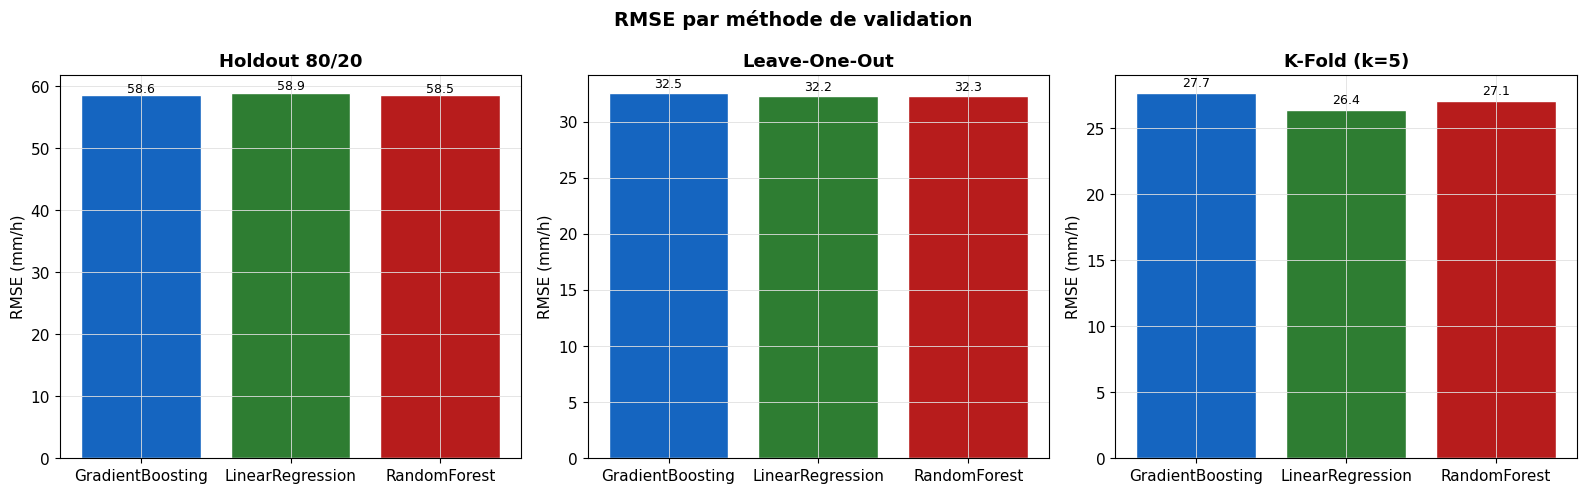

fig3 sauvegardée


In [11]:
# ==============================================================================
# FIGURE 3 — Comparaison RMSE par méthode et modèle
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, methode in zip(axes, methodes):
    df_m = df_global[df_global['Méthode'] == methode]
    bars = ax.bar(df_m['Modèle'], df_m['RMSE'], color=bar_colors, edgecolor='white')
    ax.set_ylabel('RMSE (mm/h)')
    ax.set_title(methode, fontweight='bold')
    for bar, val in zip(bars, df_m['RMSE']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.1f}', ha='center', fontsize=9)

plt.suptitle('RMSE par méthode de validation', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig3_comparaison_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig3 sauvegardée')

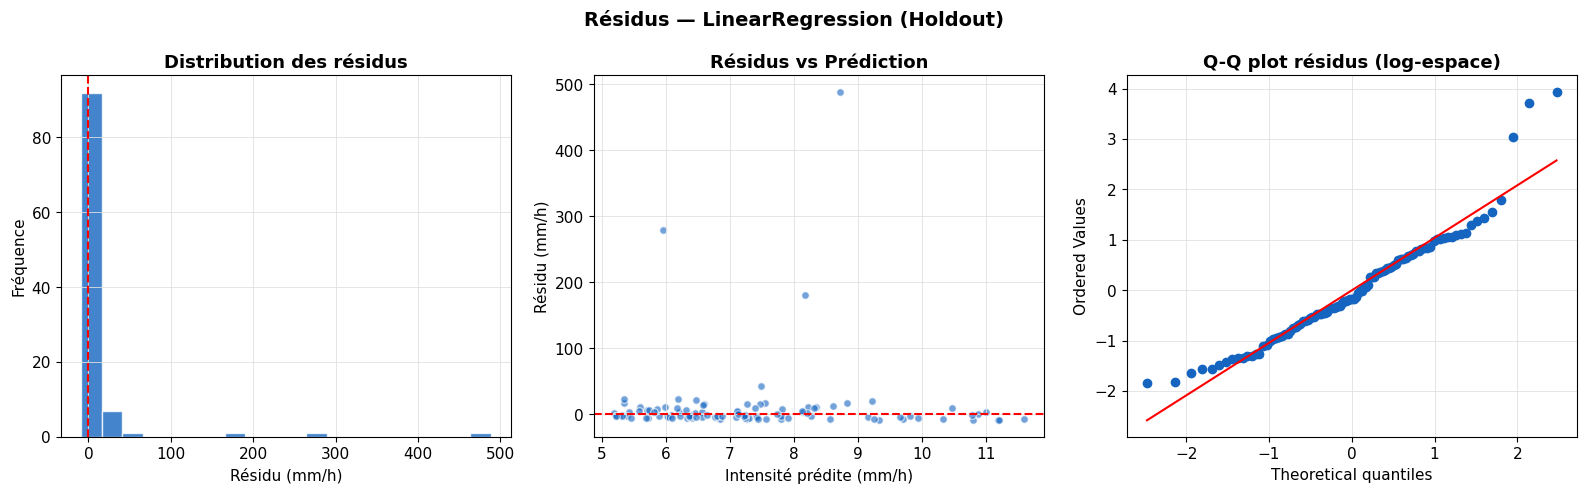

fig4 sauvegardée


In [12]:
# ==============================================================================
# FIGURE 4 — Résidus du meilleur modèle (Holdout)
# ==============================================================================

# Meilleur modèle = LinearRegression (best de n5)
best_nom = 'LinearRegression'
best_m = models[best_nom]
best_m.fit(X_train, y_train)
y_pred_best = best_m.predict(X_test)

residus_log = y_test - y_pred_best
residus_mmh = np.expm1(y_test) - np.expm1(y_pred_best)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogramme des résidus
axes[0].hist(residus_mmh, bins=20, color='#1565C0', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Résidu (mm/h)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des résidus', fontweight='bold')

# Résidus vs prédiction
axes[1].scatter(np.expm1(y_pred_best), residus_mmh, alpha=0.6, s=30,
                color='#1565C0', edgecolors='white')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Intensité prédite (mm/h)')
axes[1].set_ylabel('Résidu (mm/h)')
axes[1].set_title('Résidus vs Prédiction', fontweight='bold')

# Q-Q plot des résidus
sp_stats.probplot(residus_log, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot résidus (log-espace)', fontweight='bold')
axes[2].get_lines()[0].set_markerfacecolor('#1565C0')
axes[2].get_lines()[0].set_markeredgecolor('#1565C0')

plt.suptitle(f'Résidus — {best_nom} (Holdout)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig4_residus.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig4 sauvegardée')

---
## Résumé

| Métrique | Holdout 80/20 | Leave-One-Out | K-Fold (k=5) |
|----------|---------------|---------------|---------------|
| Principe | 1 split 80/20 | Chaque point testé | 5 plis moyennés |
| Biais | Plus élevé | Faible | Moyen |
| Variance | Plus élevée | Faible | Moyenne |
| Coût calcul | Faible | Élevé (n fit) | Moyen (5 fit) |

### Interprétation

- Si R² est **faible** (< 0.5) : la pluie journalière seule ne suffit pas  
  à prédire l'intensité max — il faudrait des features supplémentaires  
  (durée, heure, saison précise)
- Si RMSE est **élevé** : les erreurs de prédiction sont importantes,  
  la reconstitution 1980–2003 est incertaine
- Si MAPE > 30% : l'erreur relative est trop grande pour des applications  
  de dimensionnement fiable

---
*Fin du Notebook 8*